In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
import pickle

### Do a training run  

In [ ]:
start_run(config_file=Path("2basin-test-oracle.yml"), gpu=-1)

2026-01-14 17:02:57,625: Logging to /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1401_170257/output.log initialized.
2026-01-14 17:02:57,625: ### Folder structure created at /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1401_170257
2026-01-14 17:02:57,626: ### Run configurations for test_SHM
2026-01-14 17:02:57,626: experiment_name: test_SHM
2026-01-14 17:02:57,626: train_basin_file: 2_basin.txt
2026-01-14 17:02:57,627: validation_basin_file: 2_basin.txt
2026-01-14 17:02:57,627: test_basin_file: 2_basin.txt
2026-01-14 17:02:57,627: train_start_date: 2000-10-01 00:00:00
2026-01-14 17:02:57,627: train_end_date: 2014-09-30 00:00:00
2026-01-14 17:02:57,628: validation_start_date: 1990-10-01 00:00:00
2026-01-14 17:02:57,628: validation_end_date: 1999-09-30 00:00:00
2026-01-14 17:02:57,628: test_start_date: 1999-10-01 00:00:00
2026-01-14 17:02:57,628: test_end_date: 2004-09-30

### Model Evaluation
Let's load up the model and see how it did.

In [3]:
run_dir = Path("runs/test_SHM_0701_161225")
eval_run(run_dir=run_dir, period="test")

2026-01-14 17:05:58,633: Using the model weights from runs/test_SHM_0701_161225/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:02<00:00,  1.32s/it]
2026-01-14 17:06:01,275: Stored metrics at runs/test_SHM_0701_161225/test/model_epoch010/test_metrics.csv
2026-01-14 17:06:01,280: Stored results at runs/test_SHM_0701_161225/test/model_epoch010/test_results.p


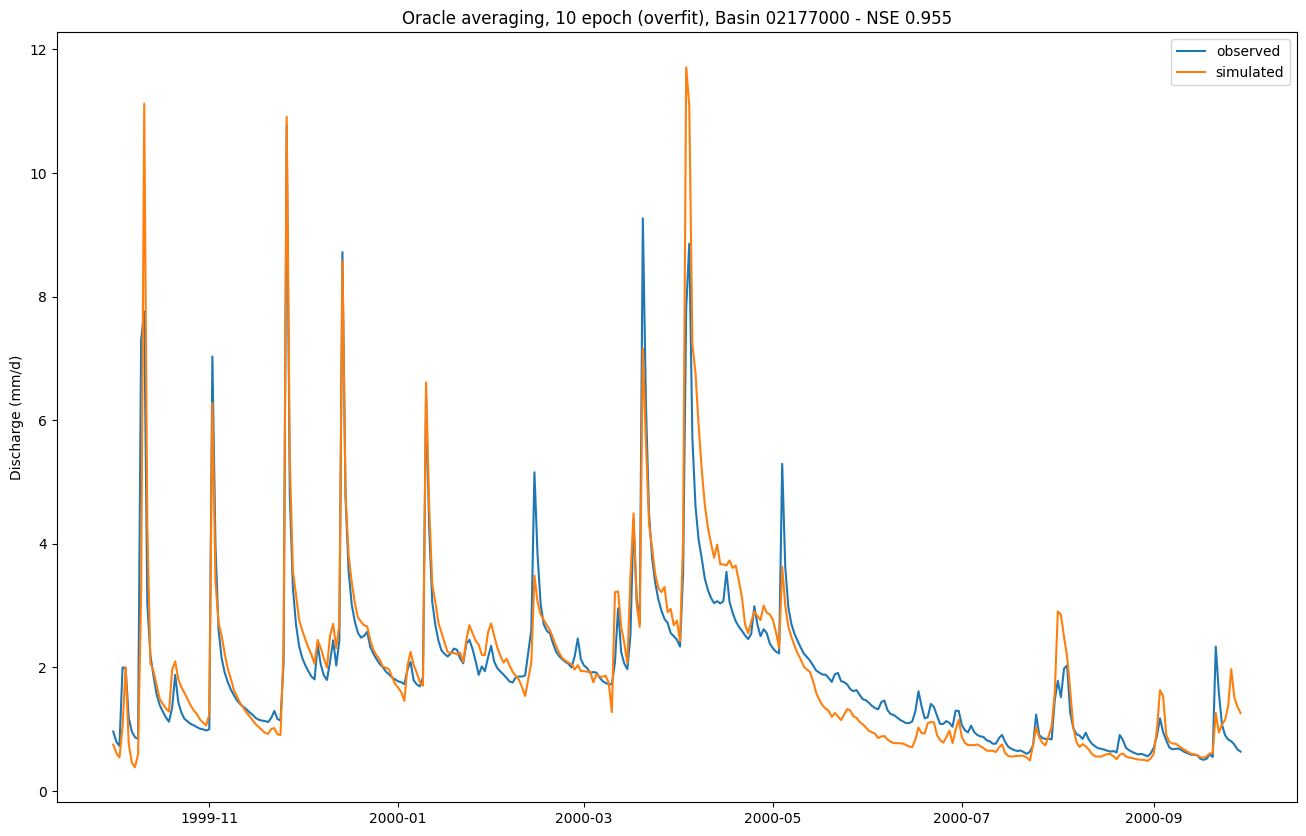

In [10]:
with open(run_dir / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
# Extract a data slice of observations and simulations
results_xr = results["02177000"]['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar data and the 1D array of time_step values
date_scalar = results_xr.coords['date'][0].values
time_step_values = results_xr.coords['time_step'].values

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
results_xr = results_xr.assign_coords(datetime=("time_step", datetime_values))

qobs = results_xr['QObs(mm/d)_obs']
qsim_oracle = results_xr['QObs(mm/d)_sim']

# extract observations and simulations
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['datetime'], qobs[0], label='observed')
ax.plot(qsim_oracle['datetime'], qsim_oracle[0], label='simulated')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Oracle averaging, 10 epoch (overfit), Basin 02177000 - NSE {results['02177000']['1D']['NSE']:.3f}")
ax.legend()

## Dynamic Parameters
Now let's test the same model and same training data, but with dynamic parameters

In [5]:
start_run(config_file=Path("2basin-test-dynamic.yml"), gpu=-1)

2026-01-14 17:09:07,452: Logging to /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1401_170907/output.log initialized.
2026-01-14 17:09:07,453: ### Folder structure created at /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1401_170907
2026-01-14 17:09:07,453: ### Run configurations for test_SHM
2026-01-14 17:09:07,454: experiment_name: test_SHM
2026-01-14 17:09:07,454: train_basin_file: 2_basin.txt
2026-01-14 17:09:07,455: validation_basin_file: 2_basin.txt
2026-01-14 17:09:07,455: test_basin_file: 2_basin.txt
2026-01-14 17:09:07,455: train_start_date: 2000-10-01 00:00:00
2026-01-14 17:09:07,456: train_end_date: 2014-09-30 00:00:00
2026-01-14 17:09:07,456: validation_start_date: 1990-10-01 00:00:00
2026-01-14 17:09:07,457: validation_end_date: 1999-09-30 00:00:00
2026-01-14 17:09:07,457: test_start_date: 1999-10-01 00:00:00
2026-01-14 17:09:07,457: test_end_date: 2004-09-30

In [6]:
run_dir = Path("runs/test_SHM_1401_170907")
eval_run(run_dir=run_dir, period="test")

2026-01-14 17:17:14,495: Using the model weights from runs/test_SHM_1401_170907/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:01<00:00,  1.26it/s]
2026-01-14 17:17:16,093: Stored metrics at runs/test_SHM_1401_170907/test/model_epoch010/test_metrics.csv
2026-01-14 17:17:16,096: Stored results at runs/test_SHM_1401_170907/test/model_epoch010/test_results.p


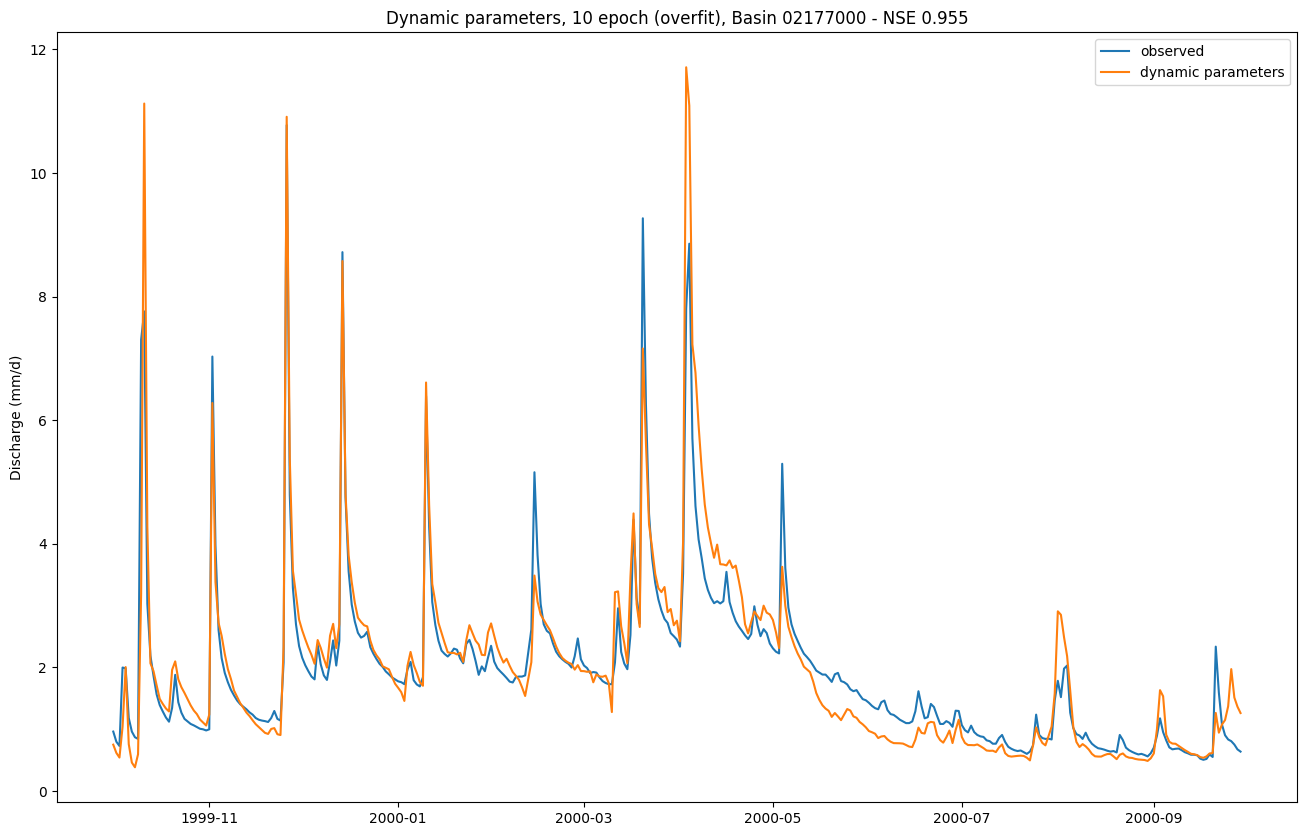

In [11]:
with open(run_dir / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
# Extract a data slice of observations and simulations
results_xr = results["02177000"]['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar data and the 1D array of time_step values
date_scalar = results_xr.coords['date'][0].values
time_step_values = results_xr.coords['time_step'].values

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
results_xr = results_xr.assign_coords(datetime=("time_step", datetime_values))

qobs = results_xr['QObs(mm/d)_obs']
qsim_dynamic = results_xr['QObs(mm/d)_sim']

# extract observations and simulations
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['datetime'], qobs[0],label='observed')
ax.plot(qsim_dynamic['datetime'], qsim_dynamic[0],label='dynamic parameters')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Dynamic parameters, 10 epoch (overfit), Basin 02177000 - NSE {results['02177000']['1D']['NSE']:.3f}")
ax.legend()

### Comparing dynamic vs oracle averaged
Let's plot them all on the same axes.

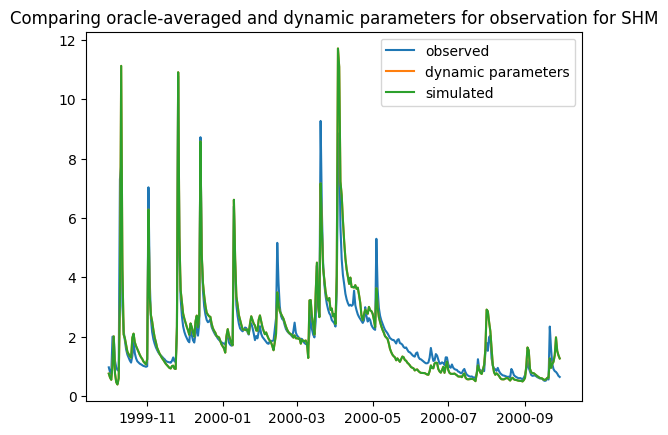

In [ ]:
# extract observations and simulations
plt.plot(qobs['datetime'], qobs[0],label='observed')
plt.plot(qsim_dynamic['datetime'], qsim_dynamic[0],label='dynamic parameters')
plt.plot(qsim_oracle['datetime'], qsim_oracle[0], label='simulated')
#plt.set_ylabel("Discharge (mm/d)")
plt.title("Comparing oracle-averaged and dynamic parameters for observation for SHM")
plt.legend()